In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
import torch
N_LETTERS: int = 27 # plus one for space

In [4]:
sorted_unique_characters = sorted(list(set(''.join(words))))
tokenizer_map = {char:index+1 for index,char in enumerate(sorted_unique_characters)}
tokenizer_map['.'] = 0
untokenizer_map = {index:char for char,index in tokenizer_map.items()}

In [5]:
CONTEXT_SIZE = 3;
BATCH_SIZE = 64;
FEATURE_DIMENSIONS = 10;
N_HIDDEN_WEIGHTS = 200;
STARTING_LEARNING_RATE = 0.1;
LEARNING_RATE_DECAY_RATE = 0.9999;
EPOCHS = int(10000)
LOG_RATE = 50

In [6]:
def build_dataset(words: list[str]):
    inputs, labels = [], []
    for word in words:
        chars = [0] * 3 + [tokenizer_map[char] for char in word] + [0]
        for i in range(0, len(chars) - CONTEXT_SIZE):
            inputs.append(chars[i:i+3])
            labels.append(chars[i+3])
    X = torch.tensor(inputs)
    Y = torch.tensor(labels)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

X_train, Y_train = build_dataset(words[:n1])
X_val, Y_val = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])

In [7]:
X_train[:40]

tensor([[ 0,  0,  0],
        [ 0,  0, 25],
        [ 0, 25, 21],
        [25, 21,  8],
        [21,  8,  5],
        [ 8,  5, 14],
        [ 5, 14,  7],
        [ 0,  0,  0],
        [ 0,  0,  4],
        [ 0,  4,  9],
        [ 4,  9, 15],
        [ 9, 15, 14],
        [15, 14,  4],
        [14,  4, 18],
        [ 4, 18,  5],
        [ 0,  0,  0],
        [ 0,  0, 24],
        [ 0, 24,  1],
        [24,  1, 22],
        [ 1, 22,  9],
        [22,  9,  5],
        [ 9,  5, 14],
        [ 0,  0,  0],
        [ 0,  0, 10],
        [ 0, 10, 15],
        [10, 15, 18],
        [15, 18,  9],
        [ 0,  0,  0],
        [ 0,  0, 10],
        [ 0, 10, 21],
        [10, 21,  1],
        [21,  1, 14],
        [ 1, 14, 12],
        [14, 12, 21],
        [12, 21,  9],
        [21,  9, 19],
        [ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 18],
        [ 5, 18,  1]])

In [8]:
for token_list in X_train[:40]:
    print([untokenizer_map[int(token)] for token in token_list])

['.', '.', '.']
['.', '.', 'y']
['.', 'y', 'u']
['y', 'u', 'h']
['u', 'h', 'e']
['h', 'e', 'n']
['e', 'n', 'g']
['.', '.', '.']
['.', '.', 'd']
['.', 'd', 'i']
['d', 'i', 'o']
['i', 'o', 'n']
['o', 'n', 'd']
['n', 'd', 'r']
['d', 'r', 'e']
['.', '.', '.']
['.', '.', 'x']
['.', 'x', 'a']
['x', 'a', 'v']
['a', 'v', 'i']
['v', 'i', 'e']
['i', 'e', 'n']
['.', '.', '.']
['.', '.', 'j']
['.', 'j', 'o']
['j', 'o', 'r']
['o', 'r', 'i']
['.', '.', '.']
['.', '.', 'j']
['.', 'j', 'u']
['j', 'u', 'a']
['u', 'a', 'n']
['a', 'n', 'l']
['n', 'l', 'u']
['l', 'u', 'i']
['u', 'i', 's']
['.', '.', '.']
['.', '.', 'e']
['.', 'e', 'r']
['e', 'r', 'a']


In [21]:
import torch.nn.functional as F

class PrimitiveModel():
    def __init__(self):
        g = torch.Generator().manual_seed(2147483647) # for reproducibility
        self.feature_lookup = torch.randn((N_LETTERS, FEATURE_DIMENSIONS), generator=g)
        self.hidden_weights = torch.randn((CONTEXT_SIZE * FEATURE_DIMENSIONS, N_HIDDEN_WEIGHTS), generator=g)
        self.hidden_biases = torch.randn((N_HIDDEN_WEIGHTS,), generator=g)
        self.output_weights = torch.randn((N_HIDDEN_WEIGHTS, N_LETTERS), generator=g)
        self.output_biases = torch.randn((N_LETTERS,), generator=g)
        self.parameters = [self.feature_lookup, self.hidden_weights, self.hidden_biases, self.output_weights, self.output_biases]
        for param in self.parameters:
            param.requires_grad = True
        self.learning_rate = STARTING_LEARNING_RATE
        self.backward_passes = 0
        self.loss_history = []
        self.x_axis = []

    def forward(self, context):
        print(self.feature_lookup.shape, context.shape, self.feature_lookup[context].shape, self.feature_lookup[context].view(-1, CONTEXT_SIZE * FEATURE_DIMENSIONS).shape, self.hidden_weights.shape)
        hidden_output = torch.tanh(self.feature_lookup[context].view(-1, CONTEXT_SIZE * FEATURE_DIMENSIONS) @ self.hidden_weights + self.hidden_biases)
        print(hidden_output.shape)
        output = hidden_output @ self.output_weights + self.output_biases
        print(self.output_weights.shape, self.output_biases.shape)
        print(output.shape)
        return output
    
    def backward(self, output, label):
        loss = F.cross_entropy(output, label)
        for param in self.parameters:
            param.grad = None
        loss.backward()
        self.learning_rate = 0.1 if self.backward_passes < 100000 else 0.01
        for param in self.parameters:
            param.data -= self.learning_rate * param.grad
        if self.backward_passes % LOG_RATE == 0:
            self.loss_history.append(loss.log10().item())
            self.x_axis.append(self.backward_passes)
        self.backward_passes += 1

model = PrimitiveModel();

In [22]:
for i in range(0, 1):
    batch_indices = torch.randint(0, X_train.shape[0], (BATCH_SIZE,))
    print(X_train.shape)
    print(batch_indices.shape)
    print(X_train[batch_indices].shape)
    model.backward(model.forward(X_train[batch_indices]), Y_train[batch_indices])
    

torch.Size([182625, 3])
torch.Size([64])
torch.Size([64, 3])
torch.Size([27, 10]) torch.Size([64, 3]) torch.Size([64, 3, 10]) torch.Size([64, 30]) torch.Size([30, 200])
torch.Size([64, 200])
torch.Size([200, 27]) torch.Size([27])
torch.Size([64, 27])


In [11]:
sum(p.nelement() for p in model.parameters) # number of parameters in total

11897

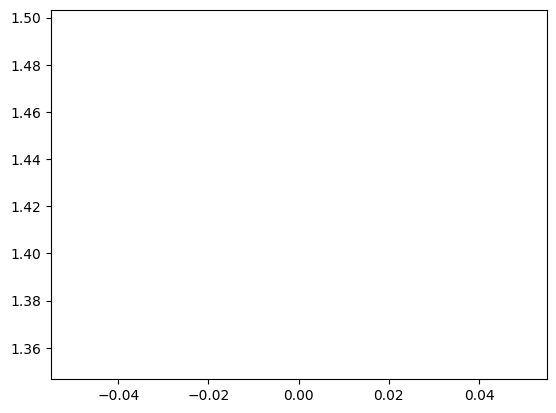

In [12]:
import matplotlib.pyplot as plt
plt.plot(model.x_axis, model.loss_history)

In [13]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * CONTEXT_SIZE # initialize with all ...
    while True:
      logits = model.forward(context)
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(untokenizer_map[i] for i in out))

AttributeError: 'list' object has no attribute 'shape'